# 05 — Regional & Channel Intelligence (Bonus)

Compute per-region and per-agent-type (EA vs IA) bind rates from the full dataset. These stats feed into Agent 4 for **dynamic escalation threshold adjustment** — regions with higher natural bind rates get different thresholds than underperforming regions.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DATA_PATH = Path("../datasets/insurance_quotes.csv")
MODELS_DIR = Path("../models")

df = pd.read_csv(DATA_PATH)
df["Policy_Bind_enc"] = (df["Policy_Bind"] == "Yes").astype(int)
overall_bind_rate = df["Policy_Bind_enc"].mean()

print(f"Dataset: {df.shape[0]} rows")
print(f"Overall bind rate: {overall_bind_rate:.4f} ({overall_bind_rate*100:.1f}%)")
print(f"Regions: {sorted(df['Region'].unique())}")
print(f"Agent types: {sorted(df['Agent_Type'].unique())}")

Dataset: 146259 rows
Overall bind rate: 0.2222 (22.2%)
Regions: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
Agent types: ['EA', 'IA']


## 1. Per-Region Bind Rates

=== Per-Region Statistics ===
Region  total_quotes  bound_quotes  bind_rate  avg_premium  bind_rate_pct
     H         18474          4167   0.225560   745.260901          22.56
     C         18137          4048   0.223190   744.356697          22.32
     F         18320          4083   0.222871   743.794990          22.29
     D         18389          4075   0.221600   743.672390          22.16
     G         18073          4003   0.221491   743.436742          22.15
     E         18324          4053   0.221185   743.063123          22.12
     A         18329          4052   0.221070   744.278284          22.11
     B         18213          4021   0.220776   744.948471          22.08


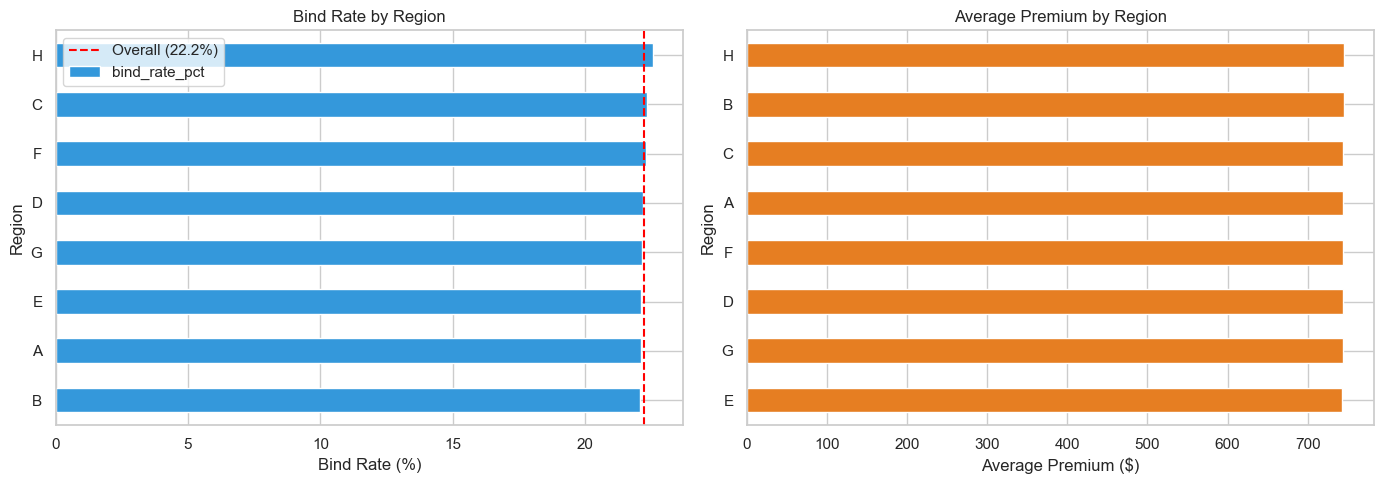

In [2]:
region_stats = df.groupby("Region").agg(
    total_quotes=("Quote_Num", "count"),
    bound_quotes=("Policy_Bind_enc", "sum"),
    bind_rate=("Policy_Bind_enc", "mean"),
    avg_premium=("Quoted_Premium", "mean"),
).reset_index()
region_stats["bind_rate_pct"] = (region_stats["bind_rate"] * 100).round(2)
region_stats = region_stats.sort_values("bind_rate", ascending=False)

print("=== Per-Region Statistics ===")
print(region_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_stats.sort_values("bind_rate_pct").plot.barh(
    x="Region", y="bind_rate_pct", ax=axes[0], color="#3498db", legend=False
)
axes[0].axvline(x=overall_bind_rate * 100, color="red", linestyle="--", label=f"Overall ({overall_bind_rate*100:.1f}%)")
axes[0].set_xlabel("Bind Rate (%)")
axes[0].set_title("Bind Rate by Region")
axes[0].legend()

region_stats.sort_values("avg_premium").plot.barh(
    x="Region", y="avg_premium", ax=axes[1], color="#e67e22", legend=False
)
axes[1].set_xlabel("Average Premium ($)")
axes[1].set_title("Average Premium by Region")

plt.tight_layout()
plt.savefig(MODELS_DIR / "regional_bind_rates.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. EA vs IA Performance

In [3]:
channel_stats = df.groupby("Agent_Type").agg(
    total_quotes=("Quote_Num", "count"),
    bound_quotes=("Policy_Bind_enc", "sum"),
    bind_rate=("Policy_Bind_enc", "mean"),
    avg_premium=("Quoted_Premium", "mean"),
).reset_index()
channel_stats["bind_rate_pct"] = (channel_stats["bind_rate"] * 100).round(2)

print("=== EA vs IA Performance ===")
print(channel_stats.to_string(index=False))

ea_rate = channel_stats.loc[channel_stats["Agent_Type"] == "EA", "bind_rate"].values[0]
ia_rate = channel_stats.loc[channel_stats["Agent_Type"] == "IA", "bind_rate"].values[0]
print(f"\nEA bind rate: {ea_rate*100:.2f}%")
print(f"IA bind rate: {ia_rate*100:.2f}%")
print(f"Difference:   {(ea_rate - ia_rate)*100:+.2f}pp")

=== EA vs IA Performance ===
Agent_Type  total_quotes  bound_quotes  bind_rate  avg_premium  bind_rate_pct
        EA        104004         23045   0.221578   744.066659          22.16
        IA         42255          9457   0.223808   744.191180          22.38

EA bind rate: 22.16%
IA bind rate: 22.38%
Difference:   -0.22pp


## 3. Region x Agent Type Cross-Analysis

=== Region x Agent Type ===
Agent_Type     EA     IA
Region                  
A           22.18  21.92
B           22.10  22.03
C           22.07  22.96
D           21.86  22.91
E           22.02  22.35
F           22.19  22.53
G           22.35  21.67
H           22.50  22.69


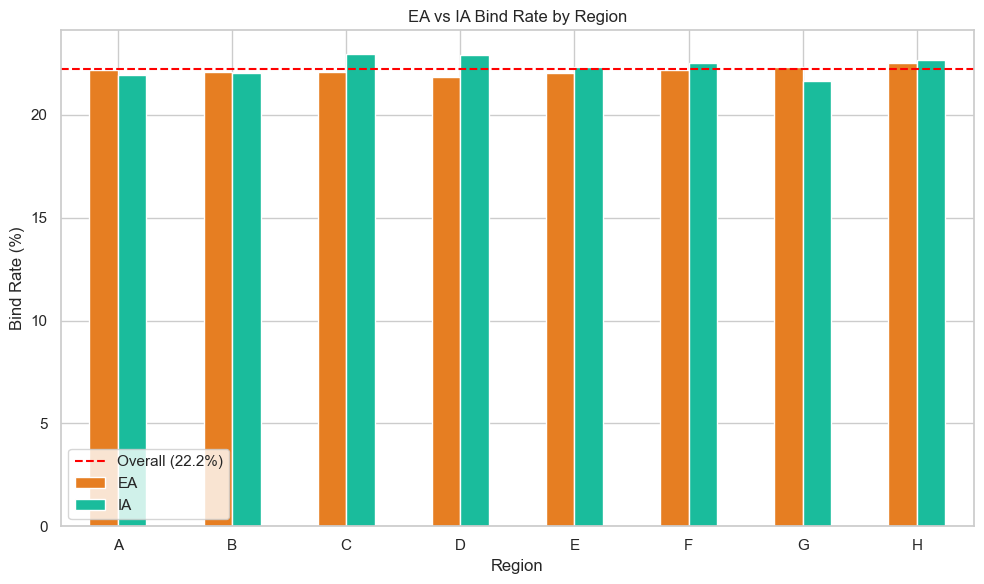

In [4]:
cross_stats = df.groupby(["Region", "Agent_Type"]).agg(
    total_quotes=("Quote_Num", "count"),
    bound_quotes=("Policy_Bind_enc", "sum"),
    bind_rate=("Policy_Bind_enc", "mean"),
    avg_premium=("Quoted_Premium", "mean"),
).reset_index()
cross_stats["bind_rate_pct"] = (cross_stats["bind_rate"] * 100).round(2)

print("=== Region x Agent Type ===")
pivot = cross_stats.pivot_table(index="Region", columns="Agent_Type", values="bind_rate_pct")
print(pivot.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot.bar(ax=ax, color=["#e67e22", "#1abc9c"])
ax.axhline(y=overall_bind_rate * 100, color="red", linestyle="--", label=f"Overall ({overall_bind_rate*100:.1f}%)")
ax.set_ylabel("Bind Rate (%)")
ax.set_title("EA vs IA Bind Rate by Region")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(MODELS_DIR / "regional_ea_vs_ia.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Dynamic Threshold Computation

Agent 4 adjusts escalation thresholds per region.

- Regions with **higher** bind rates get **lower** auto-approve thresholds.
- Regions with **lower** bind rates get **higher** thresholds.

To avoid near-flat thresholds when bind rates are close, we scale by **percentage-point difference** instead of raw decimal difference and apply guardrail bounds.

In [5]:
BASE_AUTO_APPROVE_THRESHOLD = 75.0
# Threshold points to move for each 1.0 percentage-point bind-rate difference vs overall.
SCALE_PER_PERCENT_POINT = 2.0
MIN_THRESHOLD = 72.0
MAX_THRESHOLD = 78.0


def compute_dynamic_threshold(region_bind_rate, overall_rate, base=BASE_AUTO_APPROVE_THRESHOLD):
    delta_pp = (region_bind_rate - overall_rate) * 100.0
    adjustment = delta_pp * SCALE_PER_PERCENT_POINT
    threshold = base - adjustment
    threshold = max(MIN_THRESHOLD, min(MAX_THRESHOLD, threshold))
    return round(threshold, 1), round(delta_pp, 2), round(adjustment, 2)


region_thresholds = {}
for _, row in region_stats.iterrows():
    region = row["Region"]
    rate = row["bind_rate"]
    threshold, delta_pp, adjustment = compute_dynamic_threshold(rate, overall_bind_rate)
    region_thresholds[region] = {
        "bind_rate": round(rate, 4),
        "bind_rate_pct": round(rate * 100, 2),
        "delta_vs_overall_pp": delta_pp,
        "threshold_adjustment": adjustment,
        "auto_approve_threshold": threshold,
        "total_quotes": int(row["total_quotes"]),
        "avg_premium": round(row["avg_premium"], 2),
    }

channel_thresholds = {}
for _, row in channel_stats.iterrows():
    agent_type = row["Agent_Type"]
    rate = row["bind_rate"]
    threshold, delta_pp, adjustment = compute_dynamic_threshold(rate, overall_bind_rate)
    channel_thresholds[agent_type] = {
        "bind_rate": round(rate, 4),
        "bind_rate_pct": round(rate * 100, 2),
        "delta_vs_overall_pp": delta_pp,
        "threshold_adjustment": adjustment,
        "auto_approve_threshold": threshold,
        "total_quotes": int(row["total_quotes"]),
        "avg_premium": round(row["avg_premium"], 2),
    }

print("=== Dynamic Thresholds by Region ===")
print(f"{'Region':<8} {'Bind Rate':>10} {'Delta(pp)':>10} {'Adjust':>10} {'Threshold':>10} {'vs Base':>8}")
print("-" * 64)
for region in sorted(region_thresholds.keys()):
    info = region_thresholds[region]
    diff = info["auto_approve_threshold"] - BASE_AUTO_APPROVE_THRESHOLD
    print(
        f"{region:<8} {info['bind_rate_pct']:>9.2f}% {info['delta_vs_overall_pp']:>+9.2f} "
        f"{info['threshold_adjustment']:>+9.2f} {info['auto_approve_threshold']:>10.1f} {diff:>+7.1f}"
    )

print(f"\n=== Dynamic Thresholds by Channel ===")
for agent_type, info in channel_thresholds.items():
    diff = info["auto_approve_threshold"] - BASE_AUTO_APPROVE_THRESHOLD
    print(
        f"{agent_type}: bind_rate={info['bind_rate_pct']:.2f}%, "
        f"delta={info['delta_vs_overall_pp']:+.2f}pp, "
        f"adjust={info['threshold_adjustment']:+.2f}, "
        f"threshold={info['auto_approve_threshold']:.1f} ({diff:+.1f})"
    )

print(
    f"\nConfig: base={BASE_AUTO_APPROVE_THRESHOLD:.1f}, "
    f"scale_per_pp={SCALE_PER_PERCENT_POINT:.1f}, "
    f"bounds=[{MIN_THRESHOLD:.1f}, {MAX_THRESHOLD:.1f}]"
)

=== Dynamic Thresholds by Region ===
Region    Bind Rate  Delta(pp)     Adjust  Threshold  vs Base
----------------------------------------------------------------
A            22.11%     -0.12     -0.23       75.2    +0.2
B            22.08%     -0.14     -0.29       75.3    +0.3
C            22.32%     +0.10     +0.19       74.8    -0.2
D            22.16%     -0.06     -0.12       75.1    +0.1
E            22.12%     -0.10     -0.21       75.2    +0.2
F            22.29%     +0.06     +0.13       74.9    -0.1
G            22.15%     -0.07     -0.15       75.1    +0.1
H            22.56%     +0.33     +0.67       74.3    -0.7

=== Dynamic Thresholds by Channel ===
EA: bind_rate=22.16%, delta=-0.06pp, adjust=-0.13, threshold=75.1 (+0.1)
IA: bind_rate=22.38%, delta=+0.16pp, adjust=+0.32, threshold=74.7 (-0.3)

Config: base=75.0, scale_per_pp=2.0, bounds=[72.0, 78.0]


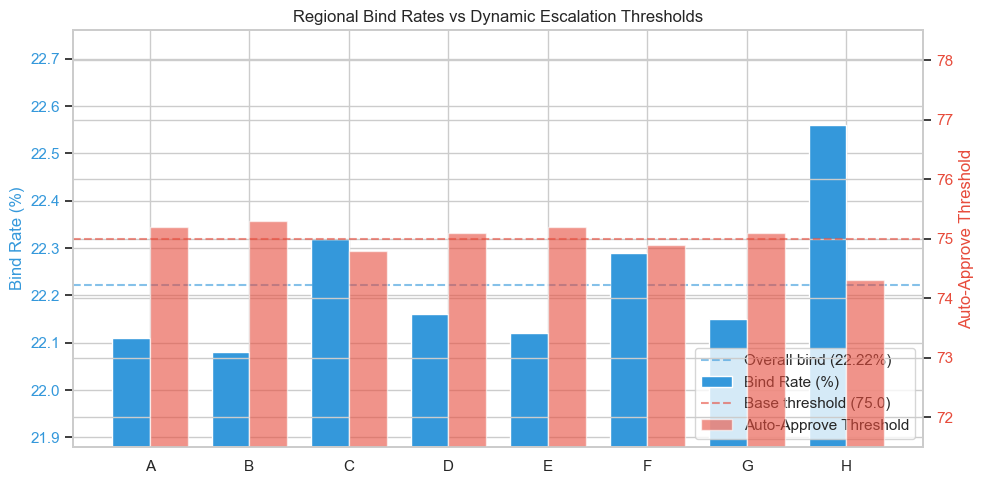

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 5))
regions_sorted = sorted(region_thresholds.keys())
rates = [region_thresholds[r]["bind_rate_pct"] for r in regions_sorted]
thresholds = [region_thresholds[r]["auto_approve_threshold"] for r in regions_sorted]

x = np.arange(len(regions_sorted))
width = 0.38

# Left axis: bind rate (%), centered tightly around observed range for readability.
bars1 = ax1.bar(x - width / 2, rates, width, label="Bind Rate (%)", color="#3498db")
ax1.axhline(y=overall_bind_rate * 100, color="#3498db", linestyle="--", alpha=0.6, label=f"Overall bind ({overall_bind_rate*100:.2f}%)")
ax1.set_ylabel("Bind Rate (%)", color="#3498db")
ax1.tick_params(axis="y", labelcolor="#3498db")
rate_min = min(rates + [overall_bind_rate * 100])
rate_max = max(rates + [overall_bind_rate * 100])
ax1.set_ylim(rate_min - 0.2, rate_max + 0.2)

# Right axis: auto-approve threshold.
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width / 2, thresholds, width, label="Auto-Approve Threshold", color="#e74c3c", alpha=0.6)
ax2.axhline(y=BASE_AUTO_APPROVE_THRESHOLD, color="#e74c3c", linestyle="--", alpha=0.6, label=f"Base threshold ({BASE_AUTO_APPROVE_THRESHOLD:.1f})")
ax2.set_ylabel("Auto-Approve Threshold", color="#e74c3c")
ax2.tick_params(axis="y", labelcolor="#e74c3c")
ax2.set_ylim(MIN_THRESHOLD - 0.5, MAX_THRESHOLD + 0.5)

ax1.set_xticks(x)
ax1.set_xticklabels(regions_sorted)
ax1.set_title("Regional Bind Rates vs Dynamic Escalation Thresholds")

# Combined legend for both axes.
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="lower right")

plt.tight_layout()
plt.savefig(MODELS_DIR / "regional_thresholds.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Save Regional Stats for Backend

In [7]:
regional_intelligence = {
    "overall_bind_rate": round(overall_bind_rate, 4),
    "base_auto_approve_threshold": BASE_AUTO_APPROVE_THRESHOLD,
    "scale_per_percent_point": SCALE_PER_PERCENT_POINT,
    "min_threshold": MIN_THRESHOLD,
    "max_threshold": MAX_THRESHOLD,
    "scale_factor": SCALE_PER_PERCENT_POINT,
    "region_thresholds": region_thresholds,
    "channel_thresholds": channel_thresholds,
    "cross_stats": cross_stats.to_dict(orient="records"),
}

joblib.dump(regional_intelligence, MODELS_DIR / "regional_stats.joblib")
print("Saved: regional_stats.joblib")
print(f"\nContents: {list(regional_intelligence.keys())}")
print(f"Regions: {list(region_thresholds.keys())}")
print(f"Channels: {list(channel_thresholds.keys())}")

Saved: regional_stats.joblib

Contents: ['overall_bind_rate', 'base_auto_approve_threshold', 'scale_per_percent_point', 'min_threshold', 'max_threshold', 'scale_factor', 'region_thresholds', 'channel_thresholds', 'cross_stats']
Regions: ['H', 'C', 'F', 'D', 'G', 'E', 'A', 'B']
Channels: ['EA', 'IA']
